In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import ast
import matplotlib.pyplot as plt

In [68]:
def read_txt(file_path):
    data = {}

    with open(file_path, "r") as f:
        for line in f:
            if ":" not in line:
                continue

            key, value = line.split(":", 1)
            key = key.strip()

            if key in ["Layers", "F1"]:
                data[key] = ast.literal_eval(value.strip())

    return data["Layers"], data["F1"]

def readData(size):
    folders = [
        Path("../Results/Llama/Initial"),
        Path("../Results/Pythia/Initial"),
        Path("../Results/Qwen/Initial")
    ]
    
    f1_list = []
    HIDDEN_STATE_LAYERS = []
    num_blocks = []
    family_f1 = []
    family_layers = []
    family_num_blocks = []
    for folder in folders:
        files = sorted(folder.glob("*.txt"))
        if size=='small':
            file=files[1]
            print(file)
            layers, f1 = read_txt(file)
    
            family_f1.append(f1)
            family_layers.append(layers)
            family_num_blocks.append(layers[-1])
        elif size=='medium':
            file=files[0]
            print(file)
            layers, f1 = read_txt(file)
    
            family_f1.append(f1)
            family_layers.append(layers)
            family_num_blocks.append(layers[-1])
        elif size=='large':
            file=files[-1]
            print(file)
            layers, f1 = read_txt(file)
    
            family_f1.append(f1)
            family_layers.append(layers)
            family_num_blocks.append(layers[-1])            
    
        f1_list.append(family_f1)
        HIDDEN_STATE_LAYERS.append(family_layers)
        num_blocks.append(family_num_blocks[0])
    return family_f1,family_layers,family_num_blocks


../Results/Llama/Initial/linear_probe_metrics_llama3b.txt
../Results/Pythia/Initial/linear_probe_metrics_pythia2-8b.txt
../Results/Qwen/Initial/linear_probe_metrics_qwen4b.txt


In [4]:
print(f1_list)
print(HIDDEN_STATE_LAYERS)
print(num_blocks)


[[0.548901875088737, 0.6161110577423741, 0.6460872545436569, 0.6391531488288856, 0.6511255664015555, 0.645247224939848, 0.6505871012207088, 0.6428200619028059], [0.546073696069422, 0.6062020310269776, 0.6165648917143268, 0.6374259150979638, 0.6298676178440432, 0.6375484966250123, 0.6477709708023315, 0.6471765335244429, 0.6433120555490995], [0.5492506755943358, 0.6151352793706243, 0.6064803386350676, 0.6304986174585213, 0.6334986419750102, 0.6355128614427799, 0.6470128372103556, 0.6479780877855928, 0.6410333410304686, 0.6454802686430035]]
[[0, 4, 8, 12, 16, 20, 24, 28], [0, 4, 8, 12, 16, 20, 24, 28, 32], [0, 4, 8, 12, 16, 20, 24, 28, 32, 36]]
[28, 32, 36]


In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=True
)

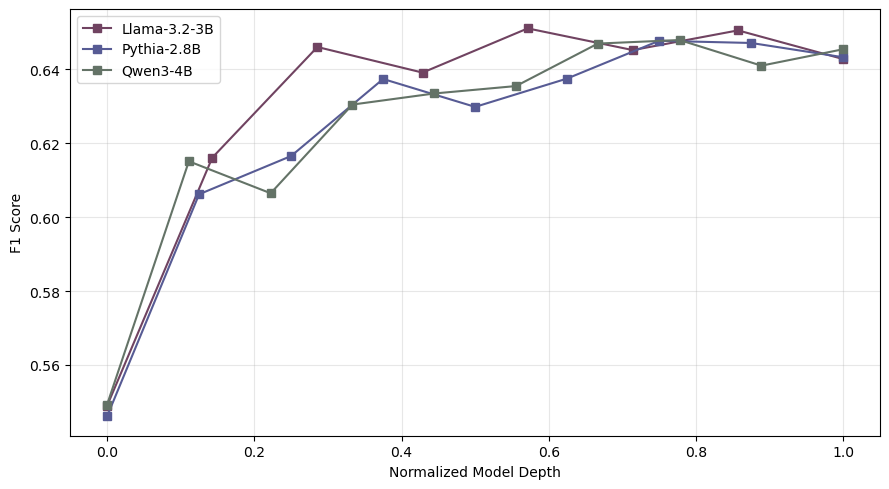

In [66]:
f1_list, HIDDEN_STATE_LAYERS,num_blocks= readData("small")
models=['Llama-3.2-3B','Pythia-2.8B', 'Qwen3-4B']
colors=['#704361','#575b94', '#647367']
plt.figure(figsize=(9, 5))
for i in range(3):
    depth = np.array(HIDDEN_STATE_LAYERS[i]) / num_blocks[i]
    plt.plot(depth, f1_list[i], marker="s", label=models[i], color=colors[i])
    plt.xlabel("Normalized Model Depth")
    plt.ylabel("F1 Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
plt.savefig("small-exp1.png")
plt.show()

../Results/Llama/Initial/linear_probe_metrics_llama13b.txt
../Results/Pythia/Initial/linear_probe_metrics_pythia12b.txt
../Results/Qwen/Initial/linear_probe_metrics_qwen14b.txt


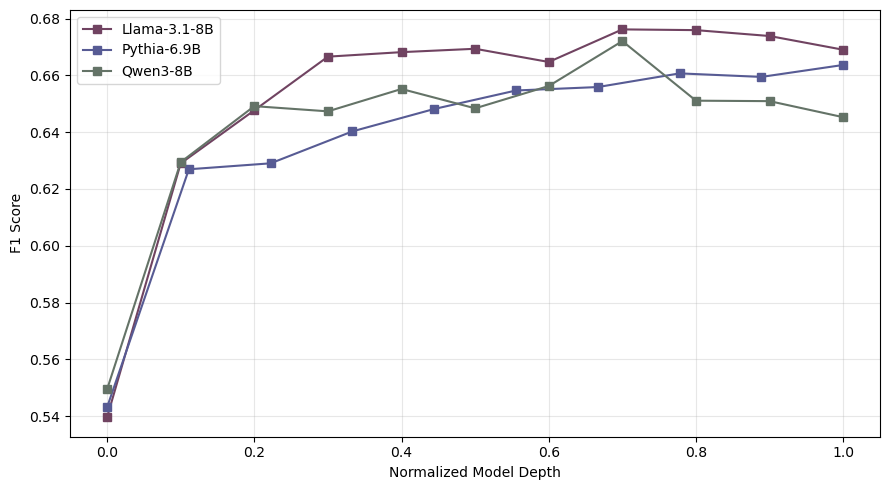

In [67]:
f1_list, HIDDEN_STATE_LAYERS,num_blocks= readData("medium")
models=['Llama-3.1-8B','Pythia-6.9B', 'Qwen3-8B']
colors=['#704361','#575b94', '#647367']

plt.figure(figsize=(9, 5))
for i in range(3):
    depth = np.array(HIDDEN_STATE_LAYERS[i]) / num_blocks[i]
    plt.plot(depth, f1_list[i], marker="s", label=models[i], color=colors[i])
    plt.xlabel("Normalized Model Depth")
    plt.ylabel("F1 Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
plt.savefig("large-exp1.png")
plt.show()

../Results/Llama/Initial/linear_probe_metrics_llama8b.txt
../Results/Pythia/Initial/linear_probe_metrics_pythia6-9b.txt
../Results/Qwen/Initial/linear_probe_metrics_qwen8b.txt


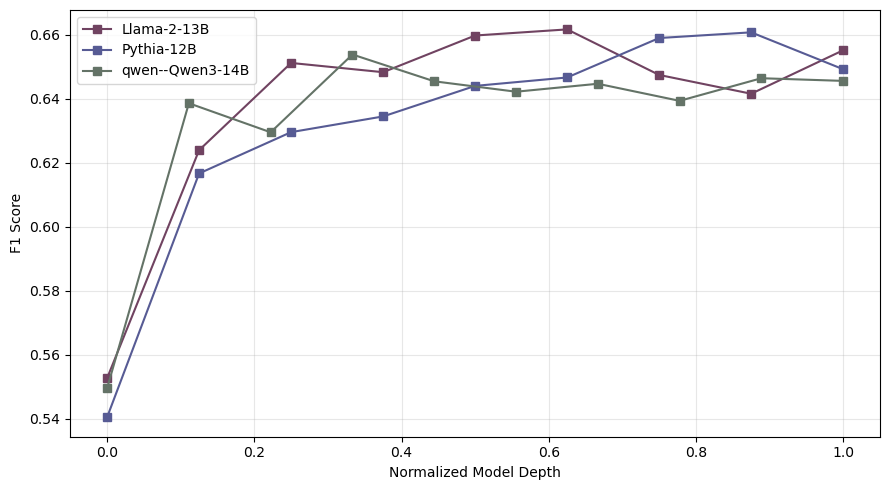

In [68]:
f1_list, HIDDEN_STATE_LAYERS,num_blocks= readData("large")
models=['Llama-2-13B','Pythia-12B', 'qwen--Qwen3-14B']
colors=['#704361','#575b94', '#647367']

plt.figure(figsize=(9, 5))
for i in range(3):
    depth = np.array(HIDDEN_STATE_LAYERS[i]) / num_blocks[i]
    plt.plot(depth, f1_list[i], marker="s", label=models[i], color=colors[i])
    plt.xlabel("Normalized Model Depth")
    plt.ylabel("F1 Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
plt.savefig("med-exp1.png")
plt.show()

../Results/Llama/Initial/linear_probe_metrics_llama3b.txt
../Results/Pythia/Initial/linear_probe_metrics_pythia2-8b.txt
../Results/Qwen/Initial/linear_probe_metrics_qwen4b.txt
../Results/Llama/Initial/linear_probe_metrics_llama13b.txt
../Results/Pythia/Initial/linear_probe_metrics_pythia12b.txt
../Results/Qwen/Initial/linear_probe_metrics_qwen14b.txt
../Results/Llama/Initial/linear_probe_metrics_llama8b.txt
../Results/Pythia/Initial/linear_probe_metrics_pythia6-9b.txt
../Results/Qwen/Initial/linear_probe_metrics_qwen8b.txt


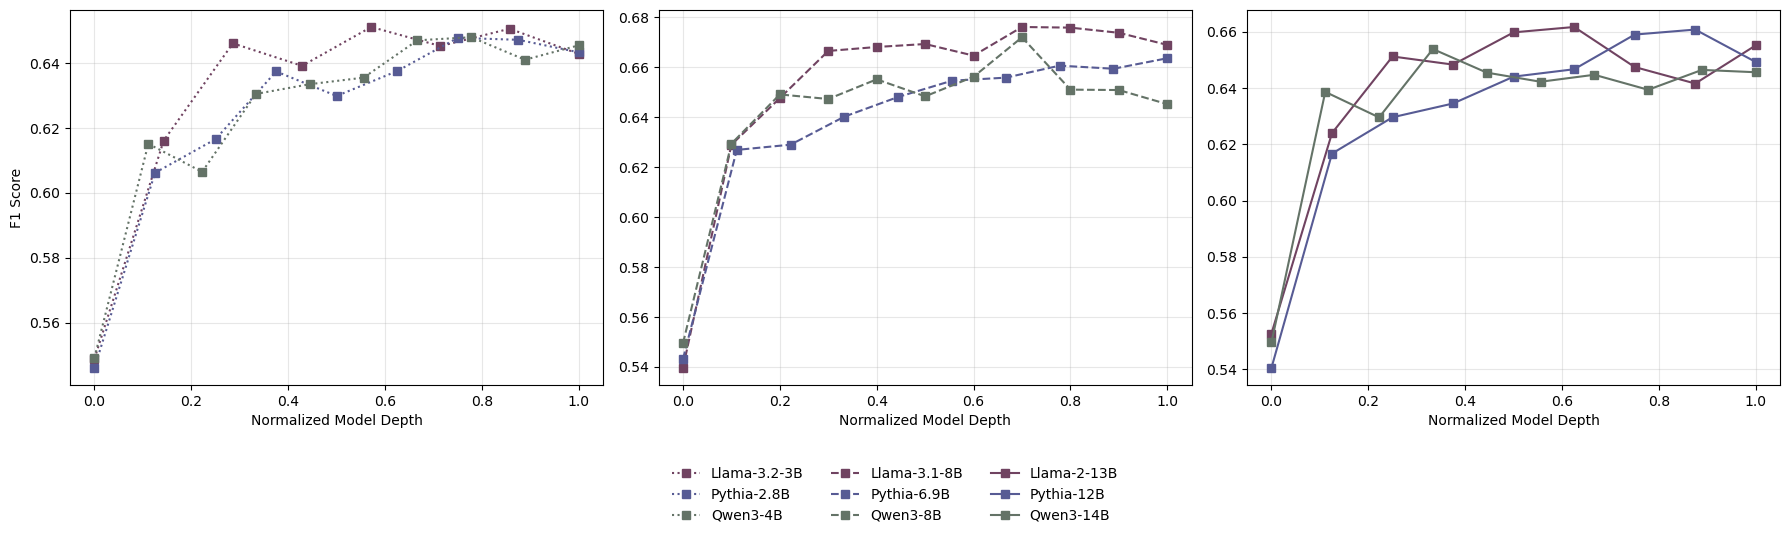

In [79]:
import numpy as np
import matplotlib.pyplot as plt

sizes = ["small", "medium", "large"]

model_names = {
    "small": ["Llama-3.2-3B", "Pythia-2.8B", "Qwen3-4B"],
    "large": ["Llama-2-13B", "Pythia-12B", "Qwen3-14B"] ,
    "medium": ['Llama-3.1-8B','Pythia-6.9B', 'Qwen3-8B'],
     
}

colors = ["#704361", "#575b94", "#647367"]



line_styles = {
    "small": ":",    # dotted
    "medium": "--",  # dashed
    "large": "-"     # solid
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, size in zip(axes, sizes):
    f1_list, hidden_layers, num_blocks = readData(size)

    for i in range(3):
        depth = np.array(hidden_layers[i]) / num_blocks[i]

        ax.plot(
            depth,
            f1_list[i],
            marker="s",
            color=colors[i],
            linestyle=line_styles[size],
            label=model_names[size][i]
        )

    # ax.set_title(model_names[size])
    ax.set_xlabel("Normalized Model Depth")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("F1 Score")

# One shared legend at the bottom
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

plt.savefig(
    "all-sizes-exp1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [60]:
def read_txt(file_path):
    data = {}

    with open(file_path, "r") as f:
        for line in f:
            if ":" not in line:
                continue

            key, value = line.split(":", 1)
            key = key.strip()

            if key in ["Layers", "F1"]:
                data[key] = ast.literal_eval(value.strip())

    return data["Layers"], data["F1"]

def readData():
    folders = [
        Path("../Results/Llama/Nonlinear"),
        Path("../Results/Pythia/Nonlinear"),
        Path("../Results/Qwen/Nonlinear")
    ]
    
    f1_list = []
    fi=[]
    HIDDEN_STATE_LAYERS = []
    num_blocks = []
    family_f1 = []
    family_layers = []
    family_num_blocks = []
    for folder in folders:
        files = sorted(folder.glob("*.txt"))
        file=files[0]
        print(file)
        layers, f1 = read_txt(file)
        print(f1)
        family_f1.append([f1[i] for i in range(len(f1)) if i%2==0])
        name=str(file).split("/")[-1].strip(".txt").split("_")[-1]
        fi.append(name)
        print(name)
        num_blocks.append(layers[-1])
    df=pd.DataFrame() 
    print("====")
    print(family_f1)
    
    df['Model']=fi
    df['Probe']="NonLinear (MLP)"
    df['Total Layers']=num_blocks
    cols=["20%", "40%","60%","80%","100%"]
    for i in range(len(cols)):
        temp=[]
        for j in range(3):
            temp.append(family_f1[j][i])
        df[f"{cols[i]} Depth"]=temp
        
    return df
readData()

../Results/Llama/Nonlinear/linear_probe_metrics_NL_llama13b.txt
[0.5621675603788846, 0.7136682586228594, 0.735733832430371, 0.7340125213775458, 0.7377785811756691, 0.7428200563466981, 0.7426982087509659, 0.7439225148028383, 0.7412919574778494, 0.7369826901139747, 0.7357969351584612]
llama13b
../Results/Pythia/Nonlinear/linear_probe_metrics_NL_pythia12b.txt
[0.5787054128320249, 0.7202347320126049, 0.7154716699933977, 0.7262708101292951, 0.7298161365185108, 0.7323162751905808, 0.7360038657426032, 0.7383662412539379, 0.7379153664560643, 0.731713348153234]
pythia12b
../Results/Qwen/Nonlinear/linear_probe_metrics_NL_qwen14b.txt
[0.5847036057537449, 0.7097014269057977, 0.7252762869563799, 0.7244806461741907, 0.725822628104505, 0.728060969891612, 0.7301370450937025, 0.7365538518343757, 0.7395938831461684, 0.7372272240597483, 0.7378178164146284]
qwen14b
====
[[0.5621675603788846, 0.735733832430371, 0.7377785811756691, 0.7426982087509659, 0.7412919574778494, 0.7357969351584612], [0.578705412832

,Model,Probe,Total Layers,20% Depth,40% Depth,60% Depth,80% Depth,100% Depth
0,llama13b,NonLinear (MLP),40,0.562168,0.735734,0.737779,0.742698,0.741292
1,pythia12b,NonLinear (MLP),36,0.578705,0.715472,0.729816,0.736004,0.737915
2,qwen14b,NonLinear (MLP),40,0.584704,0.725276,0.725823,0.730137,0.739594


In [61]:
def read_txt(file_path):
    data = {}

    with open(file_path, "r") as f:
        for line in f:
            if ":" not in line:
                continue

            key, value = line.split(":", 1)
            key = key.strip()

            if key in ["Layers", "F1"]:
                data[key] = ast.literal_eval(value.strip())

    return data["Layers"], data["F1"]

def readData():
    folders = [
        Path("../Results/Llama/Initial"),
        Path("../Results/Pythia/Initial"),
        Path("../Results/Qwen/Initial")
    ]
    
    f1_list = []
    fi=[]
    HIDDEN_STATE_LAYERS = []
    num_blocks = []
    family_f1 = []
    family_layers = []
    family_num_blocks = []
    for folder in folders:
        files = sorted(folder.glob("*.txt"))
        file=files[-1]
        print(file)
        layers, f1 = read_txt(file)
        print(f1)
        family_f1.append([f1[i] for i in range(len(f1)) if i%2==0])
        name=str(file).split("/")[-1].strip(".txt").split("_")[-1]
        fi.append(name)
        print(name)
        num_blocks.append(layers[-1])

    df=pd.DataFrame() 
    print("====")
    print(family_f1)
    
    df['Model']=fi
    df['Probe']="Linear (OvR)"
    df['Total Layers']=num_blocks
    cols=["20%", "40%","60%","80%","100%"]
    for i in range(len(cols)):
        temp=[]
        for j in range(3):
            temp.append(family_f1[j][i])
        df[f"{cols[i]} Depth"]=temp
        
    return df
readData()

../Results/Llama/Initial/linear_probe_metrics_llama8b.txt
[0.5527388759243879, 0.6239910065423037, 0.6512383910817768, 0.6483479486120367, 0.6598114136155487, 0.6617214743570026, 0.6474897021702124, 0.6416182655832112, 0.6552048266683582]
llama8b
../Results/Pythia/Initial/linear_probe_metrics_pythia6-9b.txt
[0.540518868153657, 0.6167124120479761, 0.6296224770366259, 0.6345279259579095, 0.644070768563296, 0.6466992132556187, 0.6590257972608293, 0.6608029991467138, 0.6492697044907161]
pythia6-9b
../Results/Qwen/Initial/linear_probe_metrics_qwen8b.txt
[0.5495721907545338, 0.6386489545036664, 0.6295720469669271, 0.6538738207278639, 0.6455032207212908, 0.6422506954312988, 0.644734075651799, 0.6393994655035775, 0.6464648633703028, 0.6456324016062653]
qwen8b
====
[[0.5527388759243879, 0.6512383910817768, 0.6598114136155487, 0.6474897021702124, 0.6552048266683582], [0.540518868153657, 0.6296224770366259, 0.644070768563296, 0.6590257972608293, 0.6492697044907161], [0.5495721907545338, 0.6295720

,Model,Probe,Total Layers,20% Depth,40% Depth,60% Depth,80% Depth,100% Depth
0,llama8b,Linear (OvR),32,0.552739,0.651238,0.659811,0.647490,0.655205
1,pythia6-9b,Linear (OvR),32,0.540519,0.629622,0.644071,0.659026,0.649270
2,qwen8b,Linear (OvR),36,0.549572,0.629572,0.645503,0.644734,0.646465


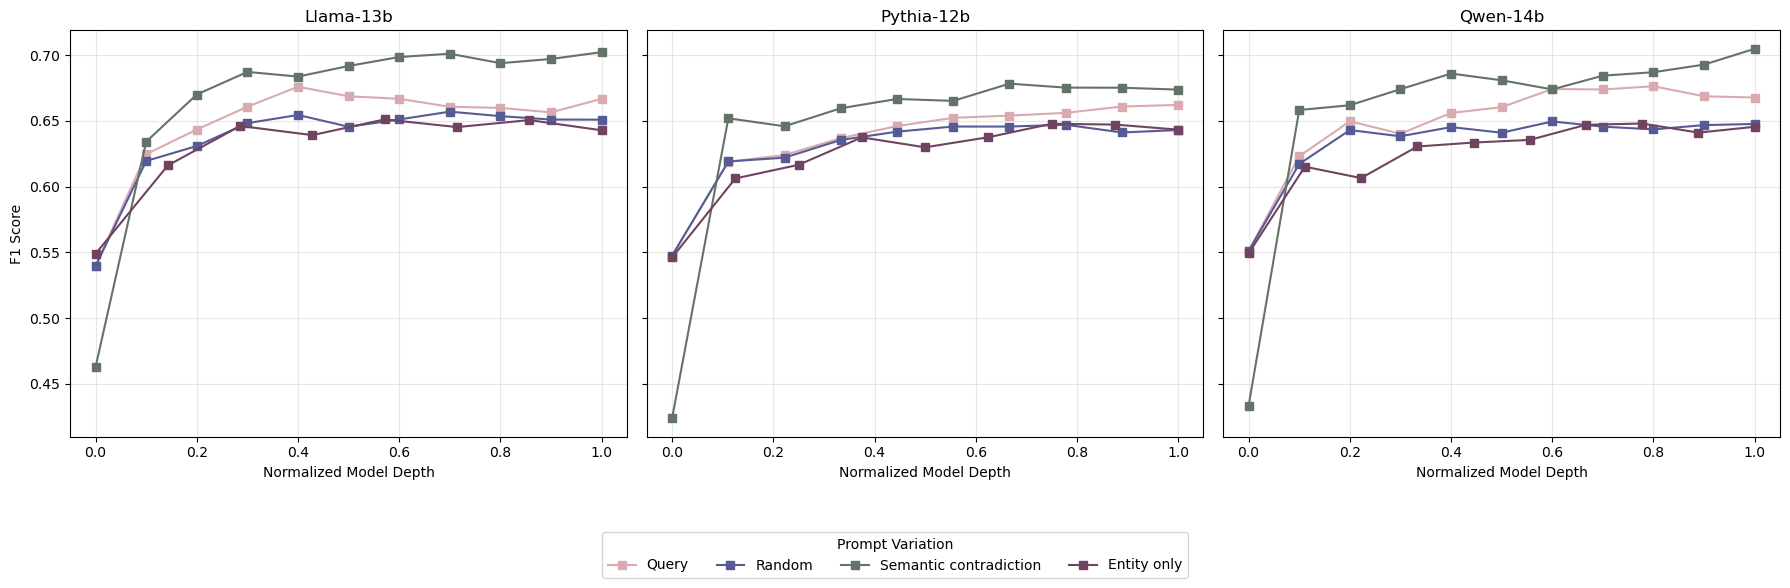

In [67]:
from pathlib import Path
import ast
import re
import numpy as np
import matplotlib.pyplot as plt


def read_txt(file_path):
    data = {}

    with open(file_path, "r") as f:
        for line in f:
            if ":" not in line:
                continue

            key, value = line.split(":", 1)
            key = key.strip()

            if key in ["Layers", "F1"]:
                data[key] = ast.literal_eval(value.strip())

    return data["Layers"], data["F1"]


def get_condition(filename):
    name = filename.lower()

    if "_rand" in name:
        return "Random"
    elif "_semantic" in name:
        return "Semantic contradiction"
    elif "_question" in name:
        return "Query"

    return None


def get_parameter_size(filename):
    name = filename.lower()

    matches = re.findall(
        r"(\d+(?:\.\d+)?)\s*([bm])",
        name
    )

    if not matches:
        return None

    value, unit = matches[-1]
    value = float(value)

    if unit == "m":
        value = value / 1000

    return value


folders = {
    "Llama": Path("../Results/Llama/Sensitivity"),
    "Pythia": Path("../Results/Pythia/Sensitivity"),
    "Qwen": Path("../Results/Qwen/Sensitivity")
}


colors = {
    "Entity only": "#704361",
    "Random": "#575b94",
    "Semantic contradiction": "#647367",
    "Query": "#d9abb0"
}


# Your entity-only results
entity_f1 = [
    [
        0.548901875088737,
        0.6161110577423741,
        0.6460872545436569,
        0.6391531488288856,
        0.6511255664015555,
        0.645247224939848,
        0.6505871012207088,
        0.6428200619028059
    ],
    [
        0.546073696069422,
        0.6062020310269776,
        0.6165648917143268,
        0.6374259150979638,
        0.6298676178440432,
        0.6375484966250123,
        0.6477709708023315,
        0.6471765335244429,
        0.6433120555490995
    ],
    [
        0.5492506755943358,
        0.6151352793706243,
        0.6064803386350676,
        0.6304986174585213,
        0.6334986419750102,
        0.6355128614427799,
        0.6470128372103556,
        0.6479780877855928,
        0.6410333410304686,
        0.6454802686430035
    ]
]


entity_layers = [
    [0, 4, 8, 12, 16, 20, 24, 28],
    [0, 4, 8, 12, 16, 20, 24, 28, 32],
    [0, 4, 8, 12, 16, 20, 24, 28, 32, 36]
]


entity_blocks = [28, 32, 36]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=True
)


for family_index, (ax, (family, folder)) in enumerate(
    zip(axes, folders.items())
):

    files_info = []

    # Read all valid files for this model family
    for file in sorted(folder.glob("*.txt")):
        condition = get_condition(file.name)
        parameter_size = get_parameter_size(file.name)

        if condition is None or parameter_size is None:
            print("Skipped:", file.name)
            continue

        files_info.append({
            "file": file,
            "condition": condition,
            "parameter_size": parameter_size
        })
    if files_info:
        largest_size = max(
            item["parameter_size"]
            for item in files_info
        )

        # Plot only the largest model files
        for item in files_info:
            if item["parameter_size"] != largest_size:
                continue

            layers, f1 = read_txt(item["file"])
            num_blocks = layers[-1]

            depth = np.array(layers) / num_blocks

            ax.plot(
                depth,
                f1,
                color=colors[item["condition"]],
                # linestyle=":",
                marker="s",
                label=item["condition"]
            )

    # Plot the matching entity-only curve
    depth = (
        np.array(entity_layers[family_index])
        / entity_blocks[family_index]
    )

    ax.plot(
        depth,
        entity_f1[family_index],
        color=colors["Entity only"],
        # linestyle=":",
        marker="s",
        label="Entity only"
    )

    ax.set_title(f"{family}-{str(largest_size).strip(".0")}b")
    ax.set_xlabel("Normalized Model Depth")
    ax.grid(True, alpha=0.3)


axes[0].set_ylabel("F1 Score")

handles = []
labels = []

for ax in axes:
    current_handles, current_labels = (
        ax.get_legend_handles_labels()
    )

    handles.extend(current_handles)
    labels.extend(current_labels)


unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    title="Prompt Variation",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    frameon=True
)

for ax in axes:
    legend = ax.get_legend()

    if legend is not None:
        legend.remove()


plt.tight_layout()


plt.savefig(
    "sensitivity_by_family_large.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()